# Notebook 05: DANN with Phased Training + Deeper Adapter

## What the previous t-SNE showed and why

The polarity-aligned version produced **concentric arcs** (same direction, not overlapping).
This was progress — both arcs curved the same way. But three problems remained:

1. **Adapter too shallow**: `Dense(5, linear)` = 30 parameters. Can only rotate/scale.
   Stretching a short AI4I arc to match a long FD001 arc requires non-linear mapping.
   Fix: `5 → Dense(16, relu) → Dense(5, linear)` — enough capacity to learn the stretch.

2. **Regression collapse**: Predictions stuck at 15-35 for ALL lifecycle windows.
   The adversarial loss started competing at epoch ~20, before regression stabilised.
   Fix: **Phase 1** (epochs 0-40) = regression only, lambda=0 hard.
   **Phase 2** (epochs 40+) = gradual adversarial introduction via gamma schedule.

3. **Window imbalance**: FD001 has ~20x more windows than AI4I runs.
   The encoder's manifold is shaped entirely by source distribution.
   Fix: upweight target windows in domain loss by `n_src / n_tgt`.

In [1]:
# ── CELL 2: Imports & Setup ───────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler
from sklearn.manifold        import TSNE

from src.data_loader          import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor         import full_preprocess_pipeline
from src.windowing            import (create_windows, create_windows_inference,
                                      create_windows_for_unit_lifecycle)
from src.models.cnn_lstm_dann import build_cnn_lstm_dann, get_cnn_lstm_feature_extractor
from src.models.grl           import GradientReversalLayer
from src.evaluate             import rmse, mae

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 30
MAX_RUL     = 125
SOURCE_DS   = 'FD001'
TARGET_DS   = 'AI4I'
DANN_N_FEAT = 5
ADAPTER_DIM = 16   # hidden units in deeper adapter

AI4I_SENSOR_COLS = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

os.makedirs('../models/saved', exist_ok=True)
print(f'Source: {SOURCE_DS}  |  Target: {TARGET_DS}')
print(f'Shared dims: {DANN_N_FEAT}  |  Adapter hidden: {ADAPTER_DIM}  |  Window: {WINDOW_SIZE}')


Source: FD001  |  Target: AI4I
Shared dims: 5  |  Adapter hidden: 16  |  Window: 30


In [2]:
# ── CELL 4: Source Domain ─────────────────────────────────────────────────────
datasets = load_all_datasets(data_dir='../data/raw')

df_tr_src, df_te_src, scaler_src = full_preprocess_pipeline(
    df_train         = datasets[SOURCE_DS]['train'],
    df_test          = datasets[SOURCE_DS]['test'],
    feature_cols     = FEATURE_COLS,
    sensor_cols      = SENSOR_COLS,
    smooth           = True,
    max_rul          = MAX_RUL,
    scaler_save_path = f'../models/saved/scaler_{SOURCE_DS}.joblib'
)

corr_src   = np.array([
    np.corrcoef(df_tr_src[col].values, df_tr_src['RUL'].values)[0, 1]
    for col in FEATURE_COLS
])
TOP5_IDX   = np.argsort(np.abs(corr_src))[::-1][:DANN_N_FEAT]
TOP5_COLS  = [FEATURE_COLS[i] for i in TOP5_IDX]
SRC_POLARITY = np.sign(corr_src[TOP5_IDX])

print('Top-5 FD001 features:')
for rank, (col, idx) in enumerate(zip(TOP5_COLS, TOP5_IDX), 1):
    print(f'  {rank}. {col:<35}  corr={corr_src[idx]:+.4f}')

X_src_all, y_src_raw, _ = create_windows(df_tr_src, FEATURE_COLS, window_size=WINDOW_SIZE)
X_src = X_src_all[:, :, TOP5_IDX].astype(np.float32)
y_src = (y_src_raw / MAX_RUL).astype(np.float32)

X_src_tr, X_src_val, y_src_tr, y_src_val = train_test_split(
    X_src, y_src, test_size=0.1, random_state=42
)
print(f'\nSource: train={X_src_tr.shape}  val={X_src_val.shape}')


Top-5 FD001 features:
  1. op_setting_3                         corr=+nan
  2. sensor_4                             corr=-0.8245
  3. sensor_11                            corr=-0.8232
  4. sensor_15                            corr=-0.8193
  5. sensor_21                            corr=+0.8130

Source: train=(15867, 30, 5)  val=(1764, 30, 5)


/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [3]:
# ── CELL 6: Target Domain — polarity alignment ────────────────────────────────


def segment_ai4i_by_wear_reset(df_raw, wear_col='Tool wear [min]'):
    df = df_raw.copy().reset_index(drop=True)
    run_id, cycle_id = 0, 1
    run_ids, cycle_ids = [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i - 1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids
    df['cycle']   = cycle_ids
    return df


ai4i_raw       = pd.read_csv('../data/raw/ai4i2020.csv')
ai4i_segmented = segment_ai4i_by_wear_reset(ai4i_raw)

ai4i_scaler   = MinMaxScaler()
X_ai4i_raw    = ai4i_raw[AI4I_SENSOR_COLS].values.astype(np.float32)
X_ai4i_scaled = ai4i_scaler.fit_transform(X_ai4i_raw)

# Polarity check vs constructed RUL
ai4i_seg_tmp = ai4i_segmented.copy()
mw_tmp       = ai4i_seg_tmp.groupby('unit_id')['Tool wear [min]'].max().rename('mw')
ai4i_seg_tmp = ai4i_seg_tmp.merge(mw_tmp, on='unit_id')
rul_proxy    = (ai4i_seg_tmp['mw'] - ai4i_seg_tmp['Tool wear [min]']).clip(upper=MAX_RUL).values

corr_tgt    = np.array([
    np.corrcoef(X_ai4i_scaled[:, i], rul_proxy)[0, 1]
    for i in range(DANN_N_FEAT)
])
TGT_POLARITY = np.sign(corr_tgt)
FLIP_MASK    = (SRC_POLARITY != TGT_POLARITY)

print('Polarity alignment:')
for i, col in enumerate(AI4I_SENSOR_COLS):
    action = 'FLIP' if FLIP_MASK[i] else 'keep'
    print(f'  {col:<35}  src={SRC_POLARITY[i]:+.0f}  tgt={TGT_POLARITY[i]:+.0f}  → {action}')

# Apply flip
X_ai4i_aligned = X_ai4i_scaled.copy()
for i in range(DANN_N_FEAT):
    if FLIP_MASK[i]:
        X_ai4i_aligned[:, i] = 1.0 - X_ai4i_aligned[:, i]

tgt_feature_cols = [f'ai4i_{i}' for i in range(DANN_N_FEAT)]
df_ai4i_tmp = pd.DataFrame(X_ai4i_aligned, columns=tgt_feature_cols)
df_ai4i_tmp['unit_id'] = ai4i_segmented['unit_id'].values
df_ai4i_tmp['cycle']   = ai4i_segmented['cycle'].values
df_ai4i_tmp['RUL']     = 0.5

X_tgt, _, _ = create_windows(df_ai4i_tmp, tgt_feature_cols, window_size=WINDOW_SIZE)
X_tgt = X_tgt.astype(np.float32)

# Domain loss weight — upweight target to compensate for window count imbalance
# FD001 has ~20x more windows. Without weighting, the encoder manifold is
# shaped entirely by FD001 and AI4I lands in a peripheral region.
n_src = len(X_src_tr)
n_tgt = len(X_tgt)
TGT_DOM_WEIGHT = float(n_src / n_tgt)   # ~20x — makes each AI4I window count more
TGT_DOM_WEIGHT = min(TGT_DOM_WEIGHT, 5.0)   # cap at 5 to avoid instability

print(f'\nSource windows: {n_src}  |  Target windows: {n_tgt}')
print(f'Target domain loss weight: {TGT_DOM_WEIGHT:.2f} (capped at 5)')


Polarity alignment:
  Air temperature [K]                  src=+nan  tgt=+1  → FLIP
  Process temperature [K]              src=-1  tgt=+1  → FLIP
  Rotational speed [rpm]               src=-1  tgt=-1  → keep
  Torque [Nm]                          src=-1  tgt=+1  → FLIP
  Tool wear [min]                      src=+1  tgt=-1  → FLIP

Source windows: 15867  |  Target windows: 6420
Target domain loss weight: 2.47 (capped at 5)


In [4]:
# ── CELL 8: Build DANN + Deeper Adapter ──────────────────────────────────────
#
# DEEPER ADAPTER: 5 → Dense(16, relu) → Dense(5, linear)
# Previous Dense(5, linear) could only do affine transformation (30 params).
# The non-linear layer allows learning the STRETCH needed to map a short
# AI4I degradation arc onto the longer FD001 degradation manifold.
# This is the minimum capacity for non-linear feature space alignment.


def build_deeper_adapter(window_size, n_features, hidden_dim):
    """
    5 → Dense(hidden_dim, relu) → Dense(5, linear)
    Applied per-timestep via TimeDistributed.
    Initialised so that at epoch 0 the output ≈ input (identity behaviour).
    """
    inp = Input(shape=(window_size, n_features), name='adapter_input')

    # Hidden layer with relu
    x = layers.TimeDistributed(
        layers.Dense(hidden_dim, activation='relu', name='adapter_hidden'),
        name='adapter_td_hidden'
    )(inp)

    # Output layer — linear, initialised to zeros so initial output ≈ 0
    # We add a skip connection (inp projected) to preserve identity at epoch 0
    out_proj = layers.TimeDistributed(
        layers.Dense(n_features, use_bias=False,
                     kernel_initializer='zeros', name='adapter_out'),
        name='adapter_td_out'
    )(x)

    # Skip connection: output = learned_transform + original_input
    # At epoch 0: learned_transform ≈ 0 → output ≈ input (no-op)
    # As training progresses: adapts residual alignment
    out = layers.Add(name='adapter_residual')([inp, out_proj])

    return Model(inputs=inp, outputs=out, name='DeeperAdapter')


reg_model, dann_model = build_cnn_lstm_dann(
    window_size  = WINDOW_SIZE,
    n_features   = DANN_N_FEAT,
    filters      = [32, 64],
    kernel_size  = 3,
    lstm_units   = 128,
    feature_dim  = 64,
    reg_units    = [64, 32],
    domain_units = [32],
    dropout_rate = 0.2,
    reg_dropout  = 0.2,
    dom_dropout  = 0.2,
    alpha        = 0.0
)

adapter_model = build_deeper_adapter(WINDOW_SIZE, DANN_N_FEAT, ADAPTER_DIM)

dann_model.summary()
print(f'\nAdapter params: {adapter_model.count_params()}')
print(f'Architecture: {DANN_N_FEAT} → Dense({ADAPTER_DIM},relu) → Dense({DANN_N_FEAT}) + skip')
print(f'Residual connection: output ≈ input at epoch 0 (safe initialisation)')


Model: "CNN_LSTM_DANN_Full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 32)    │        512 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │      6,208 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool             │ (None, 15, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (None, 15, 64)    │          0 │ maxpool[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     98,816 │ cnn_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 128)       │          0 │ lstm_1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_layer       │ (None, 64)        │      8,256 │ lstm_dropout[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_1 (Dense) │ (None, 64)        │      4,160 │ feature_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_1          │ (None, 64)        │          0 │ reg_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grl                 │ (None, 64)        │          0 │ feature_layer[0]… │
│ (GradientReversalL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_2 (Dense) │ (None, 32)        │      2,080 │ reg_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_dense_1 (Dense) │ (None, 32)        │      2,080 │ grl[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_2          │ (None, 32)        │          0 │ reg_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_drop_1          │ (None, 32)        │          0 │ dom_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         33 │ reg_drop_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_output       │ (None, 1)         │         33 │ dom_drop_1[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,178 (477.26 KB)

 Trainable params: 122,178 (477.26 KB)

 Non-trainable params: 0 (0.00 B)


Adapter params: 176
Architecture: 5 → Dense(16,relu) → Dense(5) + skip
Residual connection: output ≈ input at epoch 0 (safe initialisation)


In [5]:
# ── CELL 10: Phased Training ──────────────────────────────────────────────────
#
# REGRESSION COLLAPSE FIX — two-phase training:
#
# PHASE 1 (epochs 0 → PHASE1_EPOCHS): REGRESSION ONLY
#   lambda = 0 hard (not just schedule — domain loss is NOT computed at all).
#   The encoder and regressor converge to a stable minimum on source data.
#   Val MAE should reach ~0.12-0.16 before adversarial training begins.
#   Adapter is also updated in Phase 1 via regression loss to pre-align features.
#
# PHASE 2 (epochs PHASE1_EPOCHS → EPOCHS): ADVERSARIAL INTRODUCTION
#   Lambda grows from 0 via sigmoid schedule (gamma=5).
#   Regression loss is still active — it now fights to PRESERVE the good
#   regression minimum while adversarial loss pushes toward domain confusion.
#   The encoder finds a balance between the two, not a collapsed constant.

from src.train import LSTMDANNTrainer

PHASE1_EPOCHS   = 50    # regression-only warmup
EPOCHS          = 250   # total (phase 1 + phase 2)
PHASE2_EPOCHS   = EPOCHS - PHASE1_EPOCHS
BATCH_SIZE      = 256
PATIENCE        = 40
LR_DECAY_EP     = 130   # relative to total epoch count
WARM_RESTART_EP = 180

trainer     = LSTMDANNTrainer(dann_model, alpha=0.0, lr_reg=1e-3, lr_dom=5e-4)
adapter_opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Over-sample target
n_src = len(X_src_tr)
if len(X_tgt) < n_src:
    repeat    = int(np.ceil(n_src / len(X_tgt)))
    X_tgt_use = np.tile(X_tgt, (repeat, 1, 1))[:n_src]
else:
    X_tgt_use = X_tgt[:n_src]

n_batches = int(np.ceil(n_src / BATCH_SIZE))
grl_layer = dann_model.get_layer('grl')

rul_losses, dom_losses, val_maes = [], [], []
best_val       = np.inf
no_imp         = 0
best_w_dann    = None
best_w_adapter = None


@tf.function(reduce_retracing=True)
def phase1_step(X_src_b, y_src_b):
    """Regression only — no domain loss, no adapter in the loop."""
    with tf.GradientTape() as tape:
        rul_pred, _ = dann_model(X_src_b, training=True)
        loss        = tf.reduce_mean(tf.abs(y_src_b[:, tf.newaxis] - rul_pred))
    all_vars = dann_model.trainable_variables
    grads    = tape.gradient(loss, all_vars)
    grads    = [g if g is not None else tf.zeros_like(v)
                for g, v in zip(grads, all_vars)]
    trainer.reg_opt.apply_gradients(zip(grads, all_vars))
    return loss


@tf.function(reduce_retracing=True)
def phase2_step(X_src_b, y_src_b, X_tgt_b, tgt_weight):
    """
    Adversarial step with upweighted target domain loss.
    Pass 1: regression on source
    Pass 2: domain classification with target windows upweighted
    """
    batch  = tf.shape(X_src_b)[0]
    d_src  = tf.zeros((batch, 1), dtype=tf.float32)
    d_tgt  = tf.ones((tf.shape(X_tgt_b)[0], 1), dtype=tf.float32)

    # Pass 1: regression
    with tf.GradientTape() as t1:
        rul_pred, _ = dann_model(X_src_b, training=True)
        rul_loss    = tf.reduce_mean(tf.abs(y_src_b[:, tf.newaxis] - rul_pred))

    feat_reg_vars = [v for l in dann_model.layers
                     if not l.name.startswith('dom_')
                     and l.name != 'domain_output'
                     and l.name != 'grl'
                     for v in l.trainable_variables]
    g1 = t1.gradient(rul_loss, feat_reg_vars)
    g1 = [g if g is not None else tf.zeros_like(v)
          for g, v in zip(g1, feat_reg_vars)]
    trainer.reg_opt.apply_gradients(zip(g1, feat_reg_vars))

    # Pass 2: domain adversarial with adapter + target upweighting
    X_tgt_adapted = adapter_model(X_tgt_b, training=True)
    X_both = tf.concat([X_src_b, X_tgt_adapted], axis=0)
    d_both = tf.concat([d_src,   d_tgt],          axis=0)

    # Per-sample weights: source=1.0, target=tgt_weight
    w_src    = tf.ones((batch, 1), dtype=tf.float32)
    w_tgt    = tf.fill((tf.shape(X_tgt_b)[0], 1), tgt_weight)
    weights  = tf.concat([w_src, w_tgt], axis=0)

    with tf.GradientTape() as t2:
        _, dom_pred = dann_model(X_both, training=True)
        raw_loss    = tf.keras.losses.binary_crossentropy(d_both, dom_pred)
        dom_loss    = tf.reduce_mean(raw_loss * tf.squeeze(weights, axis=1))

    dom_vars     = [v for l in dann_model.layers
                    if l.name.startswith('dom_') or l.name == 'domain_output'
                    for v in l.trainable_variables]
    adapter_vars = adapter_model.trainable_variables
    all_dom_vars = dom_vars + adapter_vars

    g2 = t2.gradient(dom_loss, all_dom_vars)
    g2 = [g if g is not None else tf.zeros_like(v)
          for g, v in zip(g2, all_dom_vars)]
    trainer.dom_opt.apply_gradients(zip(g2, all_dom_vars))

    return rul_loss, dom_loss


def sigmoid_lam(epoch_in_phase2, phase2_total, gamma=5.0):
    p = epoch_in_phase2 / max(phase2_total - 1, 1)
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)


print(f'Phase 1: epochs 0-{PHASE1_EPOCHS}  (regression only, lambda=0 hard)')
print(f'Phase 2: epochs {PHASE1_EPOCHS}-{EPOCHS}  (adversarial, gamma=5, target weight={TGT_DOM_WEIGHT:.2f})')
print(f'Convergence target: domain loss → {np.log(2):.4f}\n')

# ── PHASE 1: regression warmup ─────────────────────────────────────────────
grl_layer.alpha = tf.constant(0.0, dtype=tf.float32)
print('--- PHASE 1: Regression Warmup ---')

for epoch in range(PHASE1_EPOCHS):
    src_idx = np.random.permutation(n_src)
    ep_rul  = []

    for b in range(n_batches):
        sl  = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        rl  = phase1_step(tf.constant(X_src_tr[sl]),
                          tf.constant(y_src_tr[sl]))
        ep_rul.append(float(rl))

    mean_rul = float(np.mean(ep_rul))
    rul_losses.append(mean_rul)
    dom_losses.append(np.log(2))   # placeholder — no domain training

    vp, _ = dann_model(X_src_val, training=False)
    vm    = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val:
        best_val       = vm
        best_w_dann    = dann_model.get_weights()
        best_w_adapter = adapter_model.get_weights()
        no_imp         = 0
    else:
        no_imp += 1

    if epoch % 10 == 0:
        print(f'  [P1] Ep {epoch:03d} | RUL={mean_rul:.4f} | '
              f'ValMAE={vm:.4f} ({vm*MAX_RUL:.1f}cyc)')

phase1_best_val = best_val
print(f'\nPhase 1 complete. Best val_MAE={phase1_best_val:.4f} '
      f'({phase1_best_val*MAX_RUL:.1f} cyc)')
print(f'Restoring best Phase 1 weights before starting adversarial phase.')
dann_model.set_weights(best_w_dann)   # start phase 2 from best regression point

# Reset patience for phase 2
best_val = phase1_best_val
no_imp   = 0

# ── PHASE 2: adversarial introduction ─────────────────────────────────────
print('\n--- PHASE 2: Adversarial Introduction ---')
tgt_w_tensor = tf.constant(TGT_DOM_WEIGHT, dtype=tf.float32)

for epoch in range(EPOCHS - PHASE1_EPOCHS):
    global_ep = epoch + PHASE1_EPOCHS

    lam = sigmoid_lam(epoch, PHASE2_EPOCHS, gamma=5.0)
    grl_layer.alpha = tf.cast(lam, tf.float32)

    if global_ep == LR_DECAY_EP:
        trainer.reg_opt.learning_rate.assign(
            float(trainer.reg_opt.learning_rate) * 0.1)
        trainer.dom_opt.learning_rate.assign(
            float(trainer.dom_opt.learning_rate) * 0.1)
        print(f'  [ep {global_ep}] LR decayed x0.1')

    if global_ep == WARM_RESTART_EP:
        trainer.reg_opt.learning_rate.assign(3e-4)
        trainer.dom_opt.learning_rate.assign(5e-4)
        print(f'  [ep {global_ep}] Warm restart')

    src_idx = np.random.permutation(n_src)
    tgt_idx = np.random.permutation(len(X_tgt_use))
    ep_rul, ep_dom = [], []

    for b in range(n_batches):
        sl = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        tl = tgt_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        rl, dl = phase2_step(
            tf.constant(X_src_tr[sl]),
            tf.constant(y_src_tr[sl]),
            tf.constant(X_tgt_use[tl]),
            tgt_w_tensor
        )
        ep_rul.append(float(rl))
        ep_dom.append(float(dl))

    mean_rul = float(np.mean(ep_rul))
    mean_dom = float(np.mean(ep_dom))
    rul_losses.append(mean_rul)
    dom_losses.append(mean_dom)

    vp, _ = dann_model(X_src_val, training=False)
    vm    = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val:
        best_val       = vm
        best_w_dann    = dann_model.get_weights()
        best_w_adapter = adapter_model.get_weights()
        no_imp         = 0
    else:
        no_imp += 1

    if epoch % 20 == 0:
        print(f'  [P2] Ep {global_ep:03d} | lam={lam:.3f} | '
              f'RUL={mean_rul:.4f} | Dom={mean_dom:.4f} '
              f'(gap={abs(mean_dom-np.log(2)):.4f}) | '
              f'ValMAE={vm:.4f} | pat={no_imp}/{PATIENCE}')

    if no_imp >= PATIENCE:
        print(f'\n  Early stop ep {global_ep}. Best ValMAE={best_val:.4f}')
        break

dann_model.set_weights(best_w_dann)
adapter_model.set_weights(best_w_adapter)

# Save all artefacts
dann_model.save_weights('../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5')
dann_model.save_weights('../models/saved/cnn_lstm_dann_FD001_to_AI4I_fixed.weights.h5')
adapter_model.save_weights('../models/saved/dann_adapter.weights.h5')
np.save('../models/saved/dann_top5_feature_idx.npy',  TOP5_IDX)
np.save('../models/saved/dann_flip_mask.npy',         FLIP_MASK)
np.save('../models/saved/dann_ai4i_scaler_scale.npy', ai4i_scaler.scale_)
np.save('../models/saved/dann_ai4i_scaler_min.npy',   ai4i_scaler.min_)
np.save('../models/saved/dann_adapter_dim.npy',       np.array([ADAPTER_DIM]))

print('\nAll artefacts saved.')


Phase 1: epochs 0-50  (regression only, lambda=0 hard)
Phase 2: epochs 50-250  (adversarial, gamma=5, target weight=2.47)
Convergence target: domain loss → 0.6931

--- PHASE 1: Regression Warmup ---
  [P1] Ep 000 | RUL=0.5608 | ValMAE=0.4885 (61.1cyc)
  [P1] Ep 010 | RUL=0.2770 | ValMAE=0.2710 (33.9cyc)
  [P1] Ep 020 | RUL=0.2357 | ValMAE=0.2231 (27.9cyc)
  [P1] Ep 030 | RUL=0.2029 | ValMAE=0.1786 (22.3cyc)
  [P1] Ep 040 | RUL=0.1863 | ValMAE=0.1607 (20.1cyc)

Phase 1 complete. Best val_MAE=0.1552 (19.4 cyc)
Restoring best Phase 1 weights before starting adversarial phase.

--- PHASE 2: Adversarial Introduction ---
  [P2] Ep 050 | lam=0.000 | RUL=0.1823 | Dom=1.2201 (gap=0.5270) | ValMAE=0.1548 | pat=0/40
  [P2] Ep 070 | lam=0.246 | RUL=0.1776 | Dom=1.1199 (gap=0.4267) | ValMAE=0.1520 | pat=1/40
  [P2] Ep 090 | lam=0.464 | RUL=0.1746 | Dom=1.0734 (gap=0.3802) | ValMAE=0.1512 | pat=0/40
  [P2] Ep 110 | lam=0.637 | RUL=0.1726 | Dom=1.0524 (gap=0.3593) | ValMAE=0.1498 | pat=0/40
  [ep 130

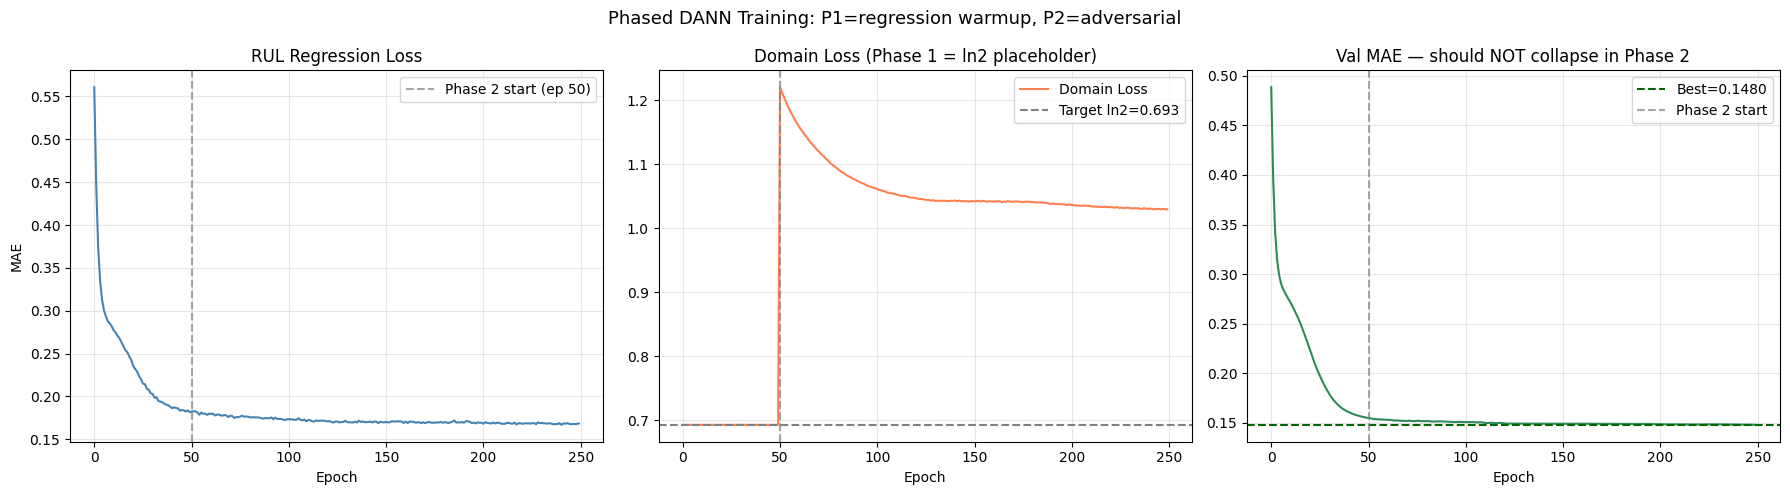

Phase 2 domain loss final:  1.0296
Convergence score:          0.3365
Best val_MAE: 0.1480 (18.5 cyc)


In [6]:
# ── CELL 12: Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep_range = range(len(rul_losses))
axes[0].plot(ep_range, rul_losses, color='steelblue', linewidth=1.5)
axes[0].axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7,
                label=f'Phase 2 start (ep {PHASE1_EPOCHS})')
axes[0].set_title('RUL Regression Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, dom_losses, color='coral', linewidth=1.5, label='Domain Loss')
axes[1].axhline(np.log(2), color='gray', linestyle='--',
                label=f'Target ln2={np.log(2):.3f}')
axes[1].axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Domain Loss (Phase 1 = ln2 placeholder)')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, val_maes, color='seagreen', linewidth=1.5)
axes[2].axhline(best_val, color='darkgreen', linestyle='--',
                label=f'Best={best_val:.4f}')
axes[2].axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7,
                label='Phase 2 start')
axes[2].set_title('Val MAE — should NOT collapse in Phase 2')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Phased DANN Training: P1=regression warmup, P2=adversarial', fontsize=13)
plt.tight_layout(); plt.show()

p2_dom = [d for d in dom_losses[PHASE1_EPOCHS:] if d != np.log(2)]
if p2_dom:
    print(f'Phase 2 domain loss final:  {p2_dom[-1]:.4f}')
    print(f'Convergence score:          {abs(p2_dom[-1]-np.log(2)):.4f}')
print(f'Best val_MAE: {best_val:.4f} ({best_val*MAX_RUL:.1f} cyc)')


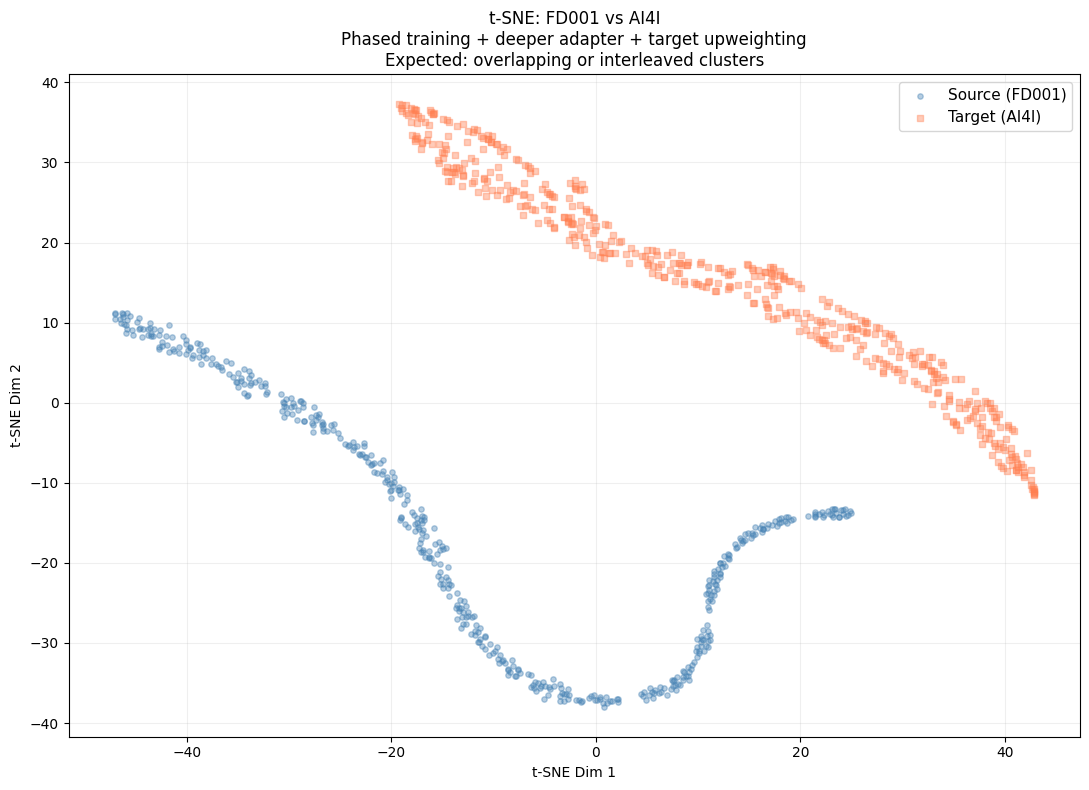

In [7]:
# ── CELL 14: t-SNE — expect overlap now ──────────────────────────────────────
feature_extractor = get_cnn_lstm_feature_extractor(dann_model)

N_VIS         = min(500, len(X_src_tr), len(X_tgt))
X_tgt_adapted = adapter_model.predict(X_tgt[:N_VIS], verbose=0, batch_size=128)

feats_src = feature_extractor.predict(X_src_tr[:N_VIS], verbose=0, batch_size=128)
feats_tgt = feature_extractor.predict(X_tgt_adapted,    verbose=0, batch_size=128)

all_feats  = np.vstack([feats_src, feats_tgt])
all_labels = ([f'Source ({SOURCE_DS})'] * N_VIS +
              [f'Target ({TARGET_DS})'] * N_VIS)

tsne        = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_result = tsne.fit_transform(all_feats)

fig, ax = plt.subplots(figsize=(11, 8))
for label, color, marker in [
    (f'Source ({SOURCE_DS})', 'steelblue', 'o'),
    (f'Target ({TARGET_DS})', 'coral',     's')
]:
    mask = [l == label for l in all_labels]
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               c=color, label=label, alpha=0.4, s=15, marker=marker)

ax.set_title(
    f't-SNE: {SOURCE_DS} vs {TARGET_DS}\n'
    f'Phased training + deeper adapter + target upweighting\n'
    f'Expected: overlapping or interleaved clusters',
    fontsize=12
)
ax.legend(fontsize=11)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


In [8]:
# ── CELL 16: Zero-Shot AI4I Evaluation ───────────────────────────────────────


def construct_ai4i_rul_toolwear(df_raw, max_rul=125):
    df       = segment_ai4i_by_wear_reset(df_raw)
    max_wear = df.groupby('unit_id')['Tool wear [min]'].max().rename('max_wear')
    df       = df.merge(max_wear, on='unit_id')
    df['RUL'] = (df['max_wear'] - df['Tool wear [min]']).clip(upper=max_rul)
    return df.drop(columns=['max_wear'])


ai4i_with_rul = construct_ai4i_rul_toolwear(ai4i_raw)

# Apply same pipeline: scaler → flip → build windows → adapter
X_eval_raw     = ai4i_raw[AI4I_SENSOR_COLS].values.astype(np.float32)
X_eval_scaled  = ai4i_scaler.transform(X_eval_raw)
X_eval_aligned = X_eval_scaled.copy()
for i in range(DANN_N_FEAT):
    if FLIP_MASK[i]:
        X_eval_aligned[:, i] = 1.0 - X_eval_aligned[:, i]

df_eval = pd.DataFrame(X_eval_aligned, columns=tgt_feature_cols)
df_eval['unit_id'] = ai4i_with_rul['unit_id'].values
df_eval['cycle']   = ai4i_with_rul['cycle'].values
df_eval['RUL']     = (ai4i_with_rul['RUL'].values / MAX_RUL).astype(np.float32)

X_eval_all, y_norm, _ = create_windows(df_eval, tgt_feature_cols,
                                        WINDOW_SIZE, rul_col='RUL')
y_true = y_norm * MAX_RUL

X_eval_adapted = adapter_model.predict(
    X_eval_all.astype(np.float32), verbose=0, batch_size=256
)
y_pred = reg_model.predict(
    X_eval_adapted.astype(np.float32), verbose=0, batch_size=256
).flatten() * MAX_RUL

ai4i_rmse = round(float(np.sqrt(np.mean((y_pred - y_true)**2))), 2)
ai4i_mae  = round(float(np.mean(np.abs(y_pred - y_true))), 2)

print(f'DANN + phased training + deeper adapter (zero-shot, full lifecycle):')
print(f'  RMSE: {ai4i_rmse:.2f} cycles')
print(f'  MAE:  {ai4i_mae:.2f} cycles')
print(f'  y_true: mean={y_true.mean():.1f} range=[{y_true.min():.0f},{y_true.max():.0f}]')

# Diagnosis: if predictions still cluster at low values, adversarial is still too strong
pred_q = np.quantile(y_pred, [0.1, 0.25, 0.5, 0.75, 0.9])
print(f'\nPrediction quantiles [10,25,50,75,90]%: {np.round(pred_q, 1)}')
print(f'Expected for healthy model: spread across 0-125 roughly matching y_true')
print(f'Collapsed model: all quantiles clustered near 15-40')


DANN + phased training + deeper adapter (zero-shot, full lifecycle):
  RMSE: 23.94 cycles
  MAE:  19.28 cycles
  y_true: mean=68.0 range=[0,125]

Prediction quantiles [10,25,50,75,90]%: [ 26.4  39.   66.9  94.3 107. ]
Expected for healthy model: spread across 0-125 roughly matching y_true
Collapsed model: all quantiles clustered near 15-40


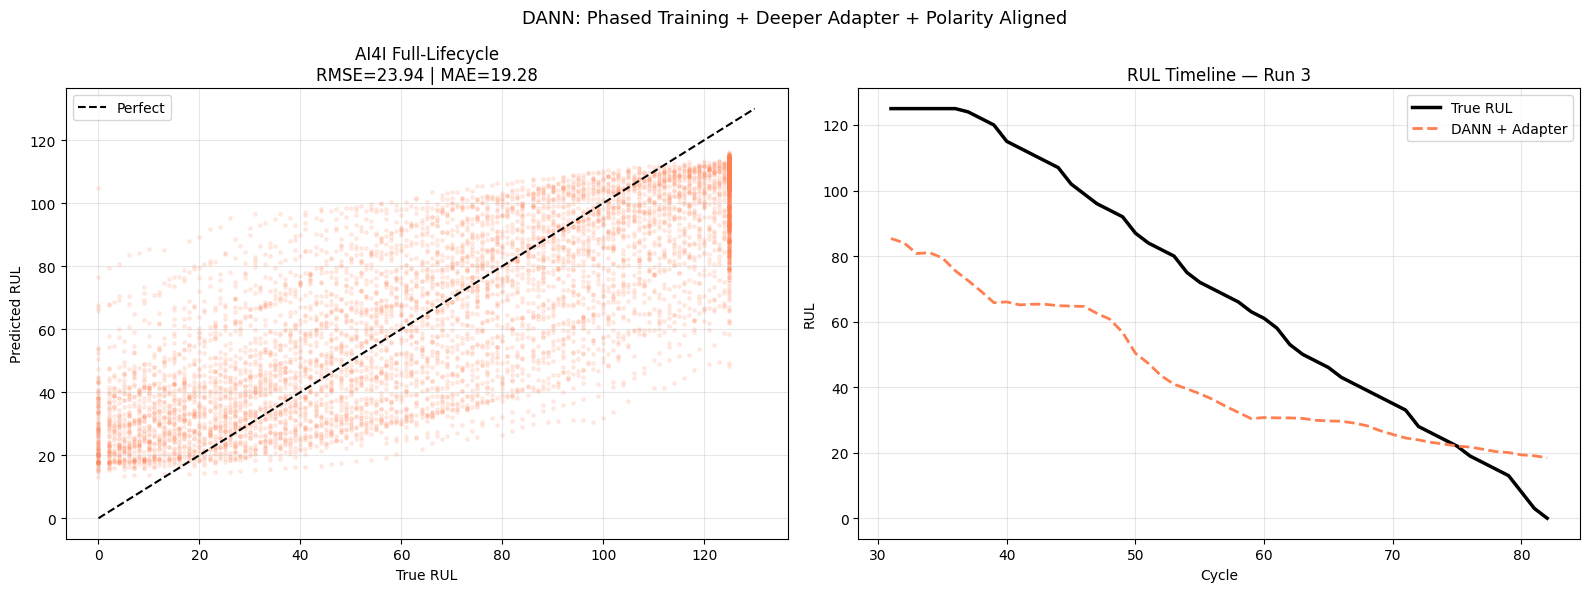

In [9]:
# ── CELL 17: RUL Scatter + Timeline ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_true, y_pred, alpha=0.12, s=6, color='coral')
lim = max(y_true.max(), y_pred.max()) + 5
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('True RUL'); axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'AI4I Full-Lifecycle\nRMSE={ai4i_rmse:.2f} | MAE={ai4i_mae:.2f}')
axes[0].legend(); axes[0].grid(alpha=0.3)

sample_run = 3
run_mask = df_eval['unit_id'] == sample_run
run_df   = df_eval[run_mask].sort_values('cycle')

if len(run_df) >= WINDOW_SIZE:
    X_run         = create_windows_for_unit_lifecycle(run_df, tgt_feature_cols, WINDOW_SIZE)
    X_run_adapted = adapter_model.predict(X_run.astype(np.float32), verbose=0)
    y_run_pred    = reg_model.predict(X_run_adapted.astype(np.float32), verbose=0
                                      ).flatten() * MAX_RUL
    y_run_true = run_df['RUL'].values[WINDOW_SIZE:] * MAX_RUL
    cycles     = run_df['cycle'].values[WINDOW_SIZE:]

    axes[1].plot(cycles, y_run_true, 'k-',   linewidth=2.5, label='True RUL')
    axes[1].plot(cycles, y_run_pred, 'coral', linewidth=2,
                 linestyle='--', label='DANN + Adapter')
    axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('RUL')
    axes[1].set_title(f'RUL Timeline — Run {sample_run}')
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('DANN: Phased Training + Deeper Adapter + Polarity Aligned', fontsize=13)
plt.tight_layout(); plt.show()
